# Creating a Test Analysis of the Benchmarking
So, this Notebook has to load in the data that is ordered (and create the index if not already created) and then match to the known lenses predictions. 

This will then form the basis of the benchmarking script!

In [1]:
import pandas as pd
import numpy as np
import sqlite3

import matplotlib.pyplot as plt

## Gathering Data

In [2]:
sess_path = '/media/team_workspaces/AnomalyMatch-IDR1-Search/benchmarking_tests/results/test-run'

In [3]:
df_known = pd.read_csv(
    '/media/team_workspaces/AnomalyMatch-IDR1-Search/benchmarking_tests/data/known_lenses/known_lenses_in_sample.csv',
    index_col = 0
)

In [4]:
db_path = f'{sess_path}/predictions.db'
con = sqlite3.connect(db_path)
con.execute("PRAGMA cache_size = -2000000")
con.execute("PRAGMA temp_store = MEMORY")
# con.execute("DROP INDEX IF EXISTS idx_results_score")
con.execute(
    "CREATE INDEX IF NOT EXISTS idx_score_covering ON results (score DESC, filename)"
)
con.commit()
con.close()

In [5]:
con = sqlite3.connect(f"file:{db_path}?mode=ro", uri=True)
print(con.execute(
    "EXPLAIN QUERY PLAN SELECT filename, score FROM results ORDER BY score DESC LIMIT 5_000"
).fetchall())
con.close()

[(4, 0, 265, 'SCAN results USING COVERING INDEX idx_score_covering')]


In [37]:
con = sqlite3.connect(f"file:{db_path}?mode=ro", uri=True)
# threshold = int(np.float16(0.90).view(np.uint16))
# scores = pd.read_sql('SELECT * FROM results WHERE score >= ?', con, params =(threshold,))
df_scored = pd.read_sql(
    'SELECT score, filename FROM results ORDER BY score DESC LIMIT 500_000',
    con,
)
con.close()

In [38]:
df_scored["score"] = df_scored["score"].to_numpy(dtype=np.uint16).view(np.float16).astype(np.float32)
df_scored.head()

,score,filename
0,1.0,-182335883567246159
1,1.0,-3527653623308720540
2,1.0,-3532184102326378830
3,1.0,-3536403303293370319
4,1.0,-3542899147308474496


## Recreating Anomaly Detection Plot

In [39]:
anomaly_ids = list(df_known.id)

In [40]:
cumul_found = []
frac_found = []
n_found = 0
for sourceid in list(df_scored.filename):
    
    if int(sourceid) in anomaly_ids:
        n_found += 1
    cumul_found.append(n_found)

    anomaly_fraction_found = n_found / len(df_known)
    
    frac_found.append(anomaly_fraction_found)

frac_found = np.array(frac_found)
cumul_found = np.array(cumul_found)

## Making Plots

In [54]:
indices = np.array(range(len(df_scored)))
percentage_indices = ( indices / 50e6 )
print(indices[:5])
print(percentage_indices[:5])

[0 1 2 3 4]
[0.e+00 2.e-08 4.e-08 6.e-08 8.e-08]


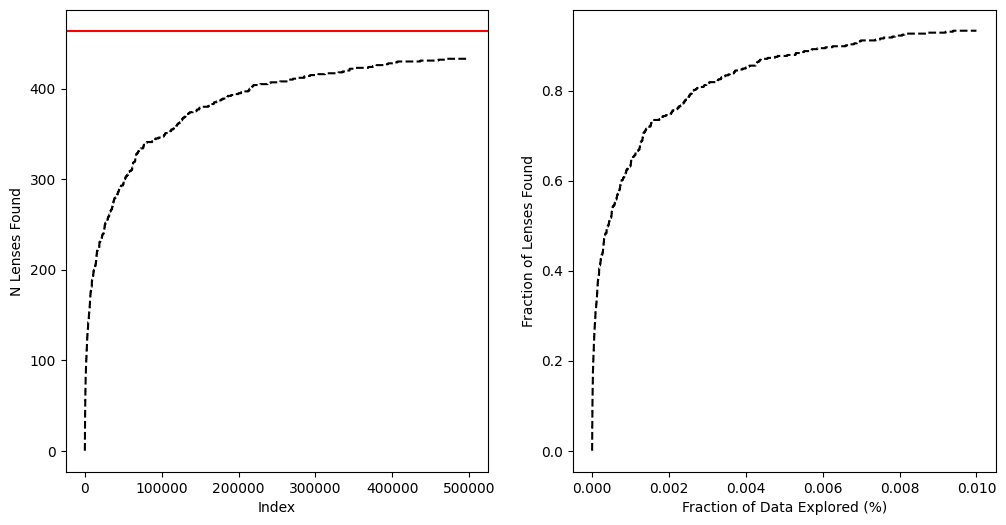

In [58]:
fig, axes = plt.subplots(figsize = (12,6), ncols = 2)
axes[0].plot(indices, cumul_found, linestyle = '--', color = 'black', label = 'N Found')
axes[0].set_xlabel('Index')
axes[0].set_ylabel('N Lenses Found')
axes[0].axhline(len(df_known), color = 'red', label = 'N Lenses')

axes[1].plot(percentage_indices, frac_found, linestyle = '--', color = 'black')
axes[1].set_xlabel('Fraction of Data Explored (%)')
axes[1].set_ylabel('Fraction of Lenses Found')

plt.show()
plt.close()

In [34]:
2e5 / 50e6

0.004

In [36]:
0.01 * 50e6

500000.0